# 🏖️ Shorelines and Beach Profiles

This notebook demonstrates how to use shoreline data derived from beach surveys at Duck Beach (FRF Field Research Facility), together with beach profile data from the same surveys. In addition, the surveyed shorelines are compared with shorelines derived from **CoastSat**.

## Duck

- **Duck Beach surveys**: Surveys with varying temporal frequency from **1980 to 2020** (blind testing period excluded).
- **Spatial resolution surveys**: **13 cross-shore profiles** covering approximately **1 km** of shoreline, with profile spacing ranging from **100 m to 200 m**.

> ⚠️ **IMPORTANT**  
> For model comparison purposes, **only profiles 1 and 1006 are used**.  
>  
> The remaining profiles are provided to the community to support model development and to better understand shoreline variability.

The figure below shows the location of the beach profiles in the Duck Beach area. Using the [ShoreShop3 website](https://shoreshop3.netlify.app/data), clicking on a profile number displays the corresponding shoreline time series and profile data. Selecting a specific date within the shoreline time series reveals the beach profile measured on that day. Up to **three profiles** can be displayed simultaneously.

<img src="assets/Profile_info.png">

## CoastSat Shorelines - North Carolina

Shorelines derived using **CoastSat** (Vos et al., 2019; http://coastsat.space/) are provided for the entire coastline of **North Carolina**. The extracted shoreline transects are spaced at **500 m** intervals. 

---

#### Before You Start

**Create a new conda environment**:
```bash
conda create -n shoreshop python=3.11 bluemath-tk wavespectra
```

**For more information**, visit the **BlueMath Toolkit Repository**:  
   [https://github.com/GeoOcean/BlueMath_tk.git](https://github.com/GeoOcean/BlueMath_tk.git)

---

> ⚠️ **IMPORTANT: Data Download Required**  
> 
> To run this Notebook, you must first download the variables of interest:
> 
> - **Download location**: [https://shoreshop3.netlify.app/data](https://shoreshop3.netlify.app/data) (use the download button)
> - **Save folder FRF_Profiles.zip  in**: `./hindcast_1980_2023/inputs/shorelines&profiles`
> - **Save folder NC_CoastSat_Shorelines.zip in**: `./hindcast_1980_2023/inputs/shorelines&profiles`
> - **Save FRF_transects.geojson in**: `./hindcast_1980_2023/inputs/shorelines&profiles`
> - **Save NC_transects.geojson in**: `./hindcast_1980_2023/inputs/shorelines&profiles`
---



In [1]:
import os

import geopandas
import pandas
from matplotlib import pyplot

#### Load geographic transect data

In [2]:
base_path = "/home/grupos/geocean/montanoj/shoreshop3-1/hindcast_1980_2023/inputs/"

FRFtransects = geopandas.read_file(
    os.path.join(base_path, "shorelines&profiles", "FRF_transects.geojson")
).set_index("profileNumber")
NCtransects = geopandas.read_file(
    os.path.join(base_path, "shorelines&profiles", "NC_transects.geojson")
).set_index("id")

Transects are numbered according to their along shore location (yFRF) in the Field Research Facility local coordinate system. Profiles are measured along transects according to the same numbering scheme.

These sets of profiles were selected for their temporal (1981-2025) and spatial range (2 km offshore). 509, 517, and 524 are truncated near the pier.

In [3]:
profileNumbers = FRFtransects.index
print(f"Profile numbers in our FRF dataset:\n{profileNumbers.values.tolist()}")

Profile numbers in our FRF dataset:
[-91.0, 1.0, 183.0, 366.0, 457.0, 509.0, 517.0, 524.0, 558.0, 640.0, 823.0, 1006.0, 1097.0]


Set up file path for the first profile

In [4]:
profNum = profileNumbers[0]

In [5]:
profPath = os.path.join(
    base_path, "shorelines&profiles", f"FRF_Profiles{os.sep}{int(profNum):05d}{os.sep}"
)

Load shoreline positions from CSV file. Dates from the blind testing period (2020 to the present) are excluded.

In [6]:
slPosDF = pandas.read_csv(
    f"{profPath}shorelinePosAtyFRF{int(profNum)}.csv", parse_dates=["time"]
)
slPosDF.set_index("time")

,xFRF,yFRF,latitude,longitude
time,,,,
1979-10-17 17:00:00,109.266,-91.0,33.567401,-85.567053
1980-10-10 18:40:00,108.435,-91.0,33.567401,-85.567061
1981-07-17 17:00:00,104.770,-91.0,33.567399,-85.567101
1981-08-23 14:00:00,104.403,-91.0,33.567399,-85.567105
1981-10-16 18:00:00,101.177,-91.0,33.567397,-85.567139
...,...,...,...,...
2019-09-23 18:55:10,113.906,-91.0,33.567404,-85.567003
2019-10-15 18:06:11,117.180,-91.0,33.567406,-85.566967
2019-10-25 17:45:08,118.015,-91.0,33.567407,-85.566959


#### Plotting shoreline positions over time with different data sources

These were calculated by interpolating between adjacent raw data points (<~1 m horizontal) with elevations above and below the Mean Water Level (MWL) contour at [-0.128 m](https://github.com/SatelliteShorelines/SDS_Benchmark/blob/main/1_preprocess_datasets.ipynb) for comparison with CoastSat.

The closest CoastSat transect was determined using the nearshore point of each transect. The data has been truncated to exclude our blind testing period (2020-present).

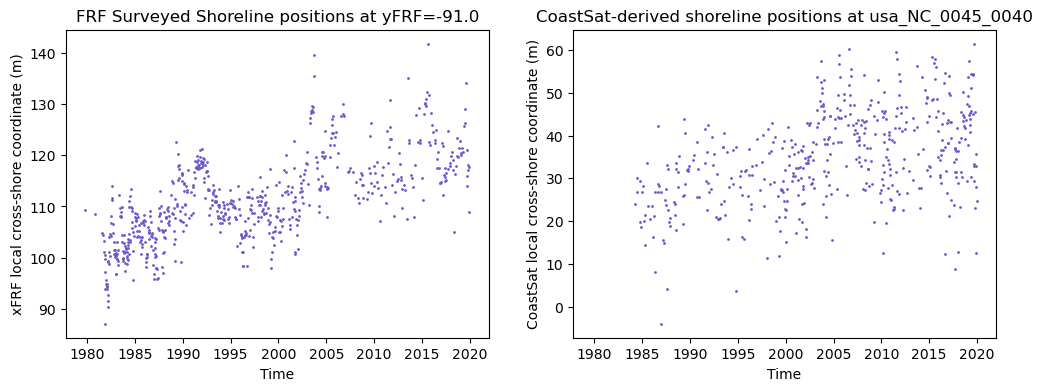

In [7]:
csStr = FRFtransects.loc[profNum]["nearest_CoastSat_id"]
cs = pandas.read_csv(
    os.path.join(
        base_path, "shorelines&profiles", "NC_CoastSat_Shorelines", f"{csStr}.csv"
    ),
    names=["time", "position"],
    parse_dates=["time"],
)

fig, (ax1, ax2) = pyplot.subplots(1, 2, sharex=True, figsize=(12, 4))

slPosDF.reset_index().plot.scatter(
    ax=ax1,
    x="time",
    y="xFRF",
    s=1,
    c="slateblue",
    ylabel="xFRF local cross-shore coordinate (m)",
    xlabel="Time",
    title=f"FRF Surveyed Shoreline positions at yFRF={profNum}",
)
cs.plot.scatter(
    ax=ax2,
    x="time",
    y="position",
    s=1,
    c="slateblue",
    # ax2.scatter(cs['time'], cs['position'], s=1)
    ylabel="CoastSat local cross-shore coordinate (m)",
    xlabel="Time",
    title=f"CoastSat-derived shoreline positions at {csStr}",
);

#### Plot shoreline positions geographically

Latitudes and longitudes are calculated from FRF coordinates using the [Coastal Model Test Bed](https://github.com/erdc/testbedutils/blob/master/geoprocess.py) and converted to WGS84 (EPSG:4326).

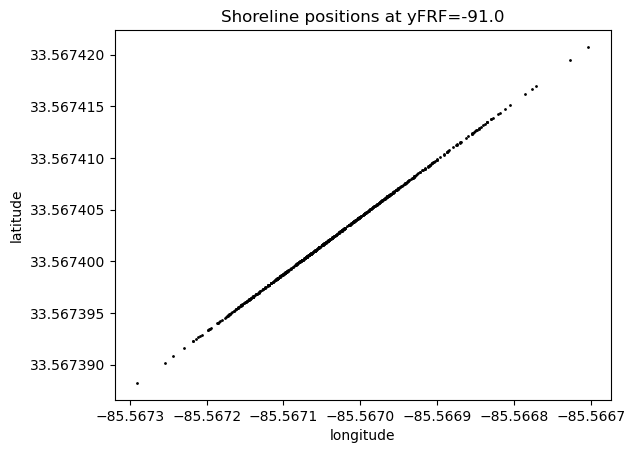

In [8]:
ax = slPosDF.plot.scatter(
    x="longitude",
    y="latitude",
    s=1,
    c="k",
    title=f"Shoreline positions at yFRF={profNum}",
)
ax.ticklabel_format(useOffset=False)

#### Load bathymetric profile from CSV file

The bathymetric data has been aggregated into the minimum, maximum, and mean over time at 1 m bin centers.

In [9]:
bathyProfDF = pandas.read_csv(
    f"{profPath}1mBinnedxFRFMeanProfileAtyFRF{int(profNum)}.csv"
)
bathyProfDF.set_index("xFRF")

,yFRF,min,max,mean,std,count,latitude,longitude
xFRF,,,,,,,,
0,-91.0,4.431,4.431,4.431,NaN,1,33.567336,-85.568226
3,-91.0,4.309,4.309,4.309,NaN,1,33.567338,-85.568194
6,-91.0,4.462,4.495,4.478,0.023,2,33.567340,-85.568162
9,-91.0,4.370,4.370,4.370,NaN,1,33.567342,-85.568130
12,-91.0,3.822,3.855,3.838,0.023,2,33.567343,-85.568097
...,...,...,...,...,...,...,...,...
1996,-91.0,-15.491,-15.112,-15.259,0.088,44,33.568524,-85.546783
1997,-91.0,-15.489,-15.063,-15.273,0.095,42,33.568524,-85.546772
1998,-91.0,-15.465,-15.063,-15.252,0.093,48,33.568525,-85.546761


#### Plot bathymetric profiles

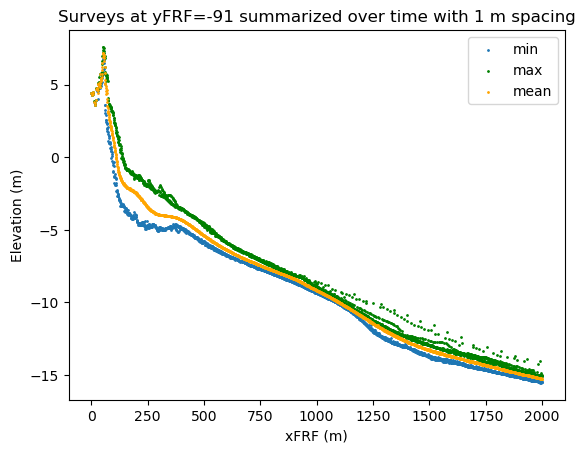

In [10]:
ax = bathyProfDF.plot.scatter(x="xFRF", y="min", s=1, label="min")
bathyProfDF.plot.scatter(ax=ax, x="xFRF", y="max", s=1, c="green", label="max")
bathyProfDF.plot.scatter(
    ax=ax,
    x="xFRF",
    y="mean",
    s=1,
    c="orange",
    label="mean",
    ylabel="Elevation (m)",
    xlabel="xFRF (m)",
    title=f"Surveys at yFRF={int(profNum)} summarized over time with 1 m spacing",
);